In [9]:
import json

file_path = "Year_1849_1865.geojson"

with open(file_path, "r", encoding="utf-8") as f:
    geojson_data = json.load(f)

Dataset loaded.
Rows: 320, Columns: 18

Columns:
['Year', 'Date', 'State', 'Sublocation', 'Location', 'Lat', 'Long', 'Description', 'Source', 'Type', 'Rioter Classification', 'Target Classification', 'Actions', 'Recorded # Killed', 'Recorded # Injured', 'Persons Named as Rioters', 'Persons Named as Targets', 'Note']


,Year,Date,State,Sublocation,Location,Lat,Long,Description,Source,Type,Rioter Classification,Target Classification,Actions,Recorded # Killed,Recorded # Injured,Persons Named as Rioters,Persons Named as Targets,Note
0,1849,1849/01,California,Dry Diggings,Dry Diggings,38.727510,-120.799800,Janurary: Three men hanged. One for alleged ho...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1849,NaN,Arkansas,Phillips Co.,Phillips Co. AR,34.379810,-90.819060,Burning of enslaved man for allegedly murderin...,"Orville W. Taylor, Negro Slavery on Arkansas (...",Racial; Slavery; Vigilante; Law,White; Vigilante,Black; Slave; Alleged Criminal; Alleged Murderer,Lethal Violence; Mutilation,1.0,NaN,NaN,NaN,PTH
2,1849,1849/05,New York,New York City,NYC,40.720368,-74.001098,May: Astor Place Riot. Long-time feud between ...,"Cook.Armies, p.24-27",Theater,Unknown,Theater; Actor; Legal; Law Officer; Military; ...,Lethal Violence,22.0,NaN,Edwin Forrest,William C. MacReady,NaN
3,1849,1849/07,Pennsylvania,Philadelphia,Philadelphia,39.901530,-75.176711,June: Fire purposefully set so a gang could at...,"Scharf and Wescott, p.691-692",Firefighter,Firefighter; Franklin Hose; Gang,Firefighter; Franklin Hose; Gang,Lethal Violence,1.0,NaN,NaN,NaN,NaN
4,1849,1849/07,Illinois,Massac Co.,"Massac Co., Illinois",37.240106,-88.724884,July: Flatheads and Regulators fight at Linn F...,"Eteheson. ""Good Men,"" p.17;Lethal Imagination,...",Vigilante; Law; Gang,Vigilante; Regulator (Vigilante); Gang; Flathead,Vigilante; Regulator (Vigilante); Gang; Flathead,Lethal Violence; Non-Lethal Violence,3.0,6.0,NaN,NaN,NaN



Shape after cleaning: (320, 18)

Counts by region:


,count
region,
West/North,245
South/Border South,75



Counts by incident group:


,count
incident_group,
Racial/Slavery-Related,188
Other,132



Raw counts by region and incident group:


incident_group,Other,Racial/Slavery-Related
region,,
South/Border South,16,59
West/North,116,129



Percentages within each region:


incident_group,Other,Racial/Slavery-Related
region,,
South/Border South,21.33,78.67
West/North,47.35,52.65


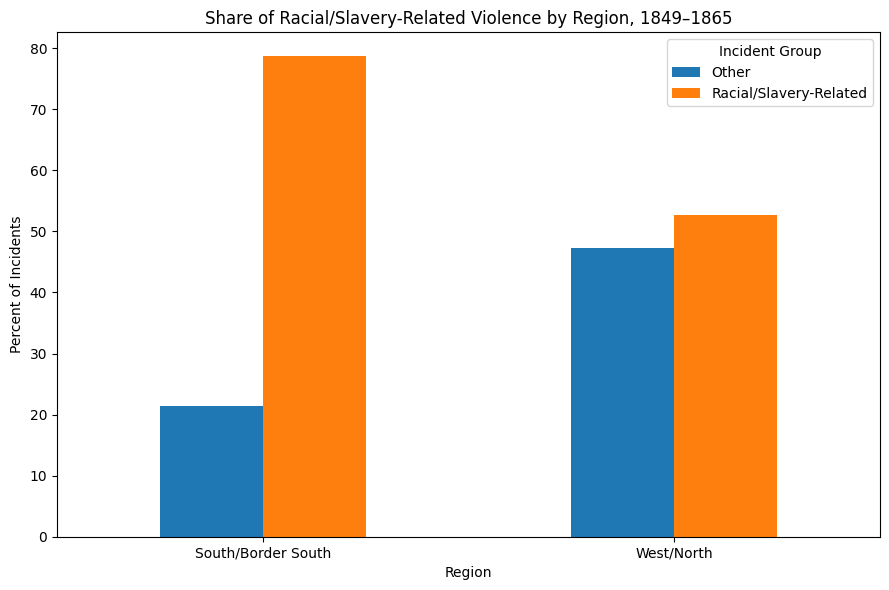

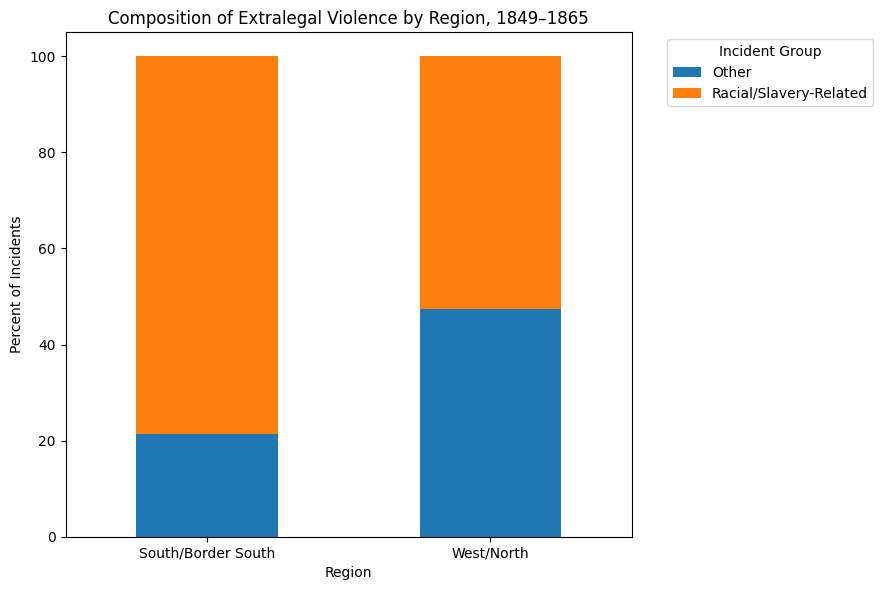


State-level counts (states with at least 4 incidents):


incident_group,Other,Racial/Slavery-Related
State,,
Colorado,25,3
Iowa,25,1
Illinois,13,0
California,12,78
Maryland,8,1
Nebraska,7,0
Kansas,6,15
New York,5,2
Pennsylvania,4,2


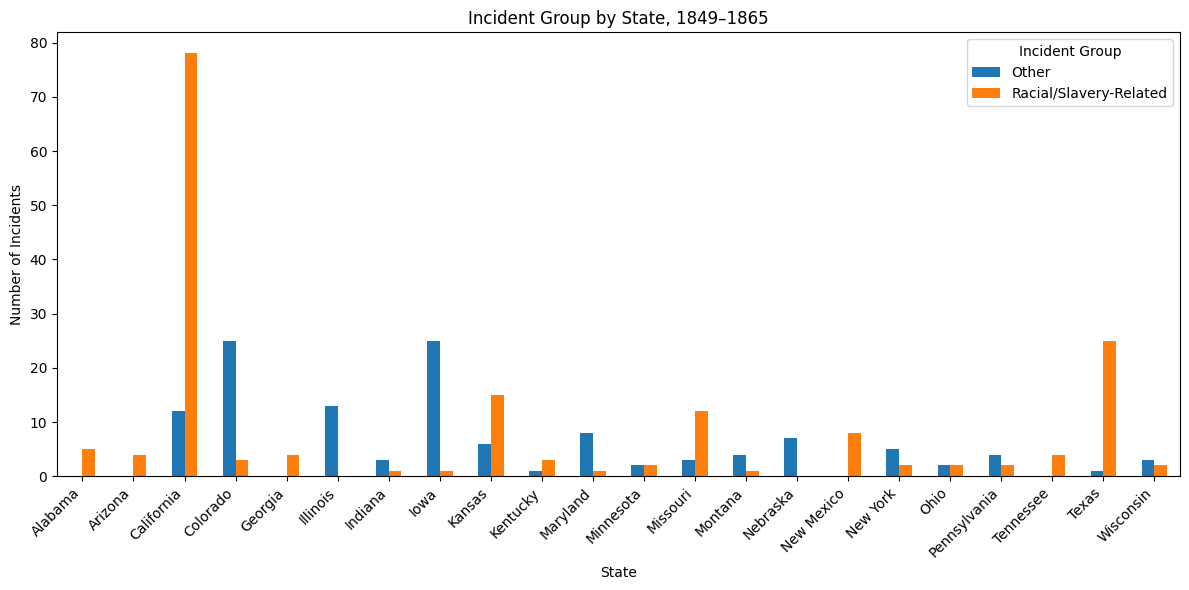


Percentages by time period:


incident_group,Other,Racial/Slavery-Related
period,,
1849–1860,34.17,65.83
1861–1865,62.50,37.50


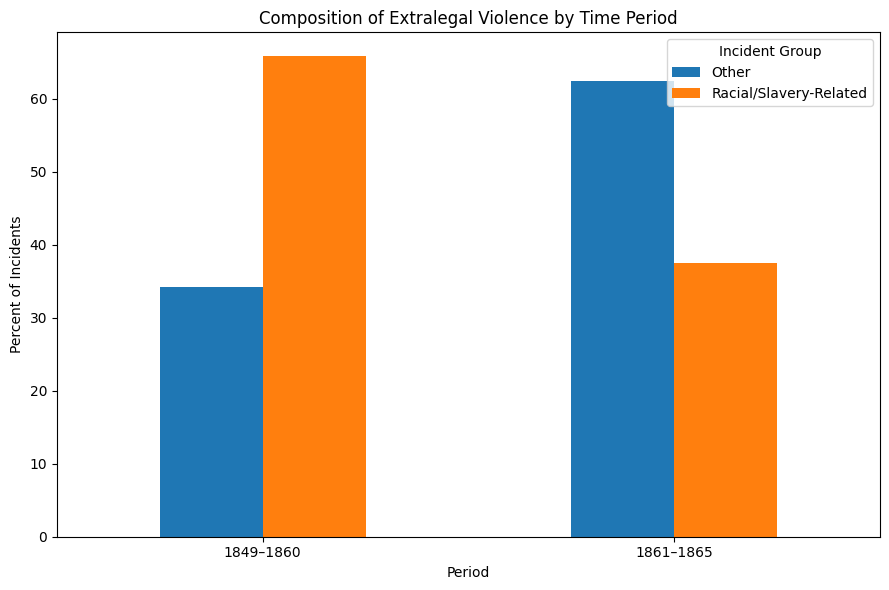


Probability of racial/slavery-related incident by region:


,probability
region,
South/Border South,0.786667
West/North,0.526531


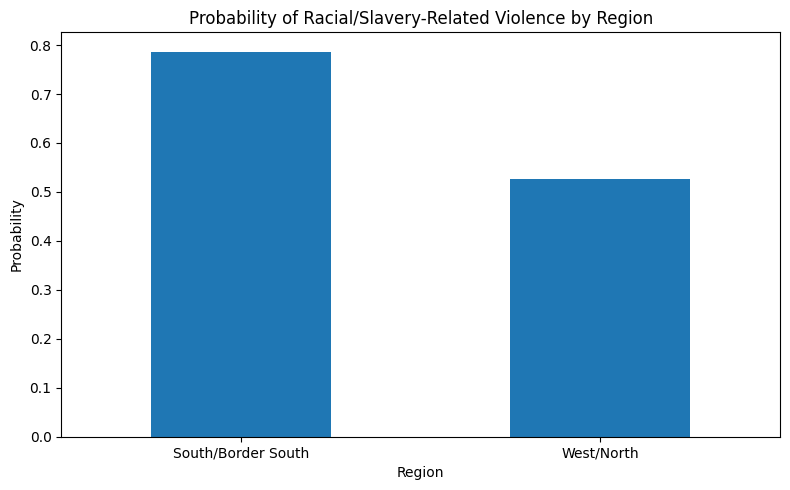


States with the highest probability of racial/slavery-related incidents:


,probability,count
State,,
Alabama,1.000000,5
Arizona,1.000000,4
Georgia,1.000000,4
Tennessee,1.000000,4
New Mexico,1.000000,8
Texas,0.961538,26
California,0.866667,90
Missouri,0.800000,15
Kentucky,0.750000,4


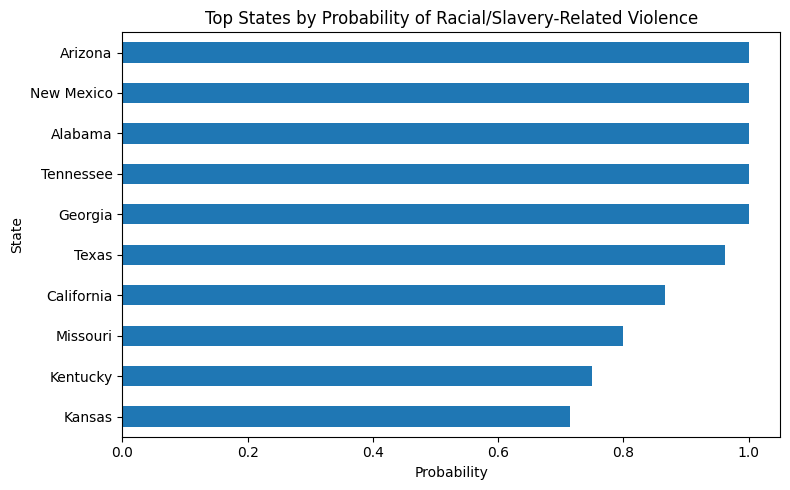


Target classifications most associated with racial/slavery-related violence:


,probability,count
Target Classification,,
Free-Soiler; Anti-Slavery; Free-Stater,1.000000,5
Black; Slave; Alleged Criminal; Alleged Sexual Assailant,1.000000,3
Black; Slave; Alleged Criminal; Alleged Murderer,1.000000,5
Mexican; Hispanic; Catholic; Alleged Criminal; Alleged Murderer; Legal; Jail; Prisoner,1.000000,4
Mexican; Hispanic; Catholic; Alleged Criminal; Alleged Thief,1.000000,10
Mexican; Hispanic; Catholic; Alleged Criminal; Alleged Murderer;,1.000000,3
Mexican; Hispanic; Catholic,1.000000,6
Mexican; Hispanic; Catholic; Alleged Murderer; Alleged Criminal,1.000000,3
Mexican; Hispanic; Catholic; Alleged Criminal; Alleged Murderer,0.977778,45


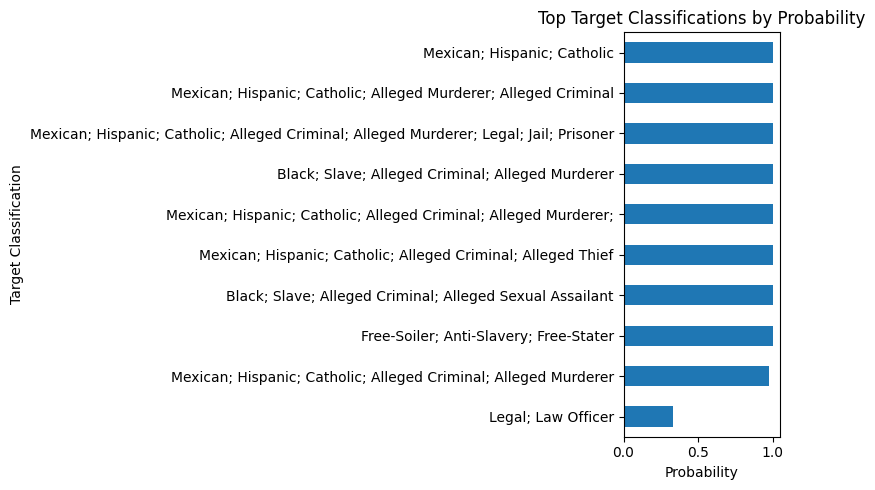


Top words in racial/slavery-related descriptions:


,count
alleged,110
murder,84
lynched,57
hanged,54
mexican,35
black,33
unknown,32
enslaved,29
killed,29
hanging,24



Top words in other descriptions:


,count
alleged,47
killed,36
horse,33
him,33
hanged,29
lynched,25
murder,23
theft,21
vigilantes,21
mob,19


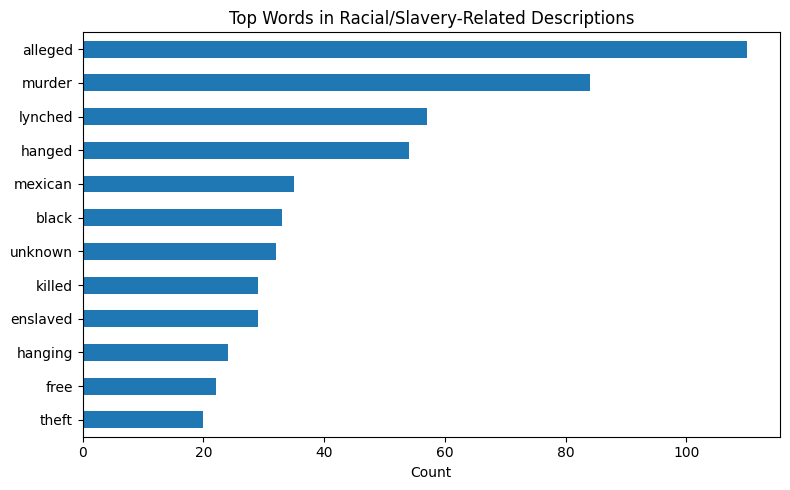

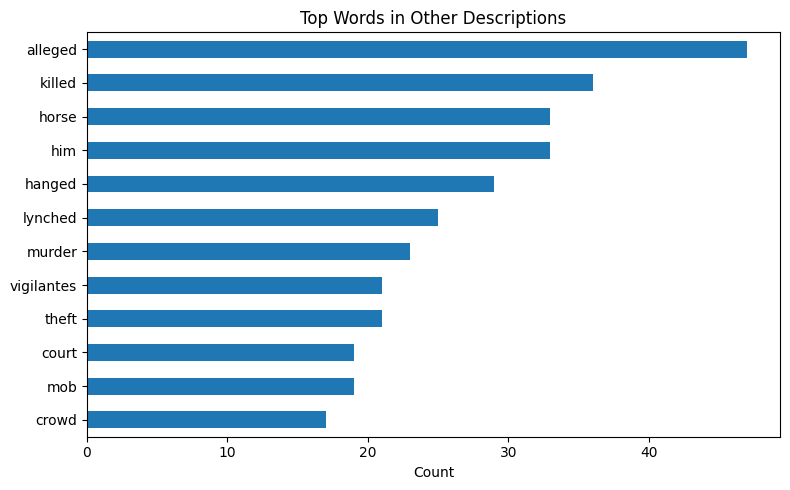


Most common words in 1849–1860 descriptions:


,count
alleged,122
murder,92
hanged,65
lynched,58
killed,46
hanging,33
unknown,31
committee,30
him,29
horse,28



Most common words in 1861–1865 descriptions:


,count
alleged,35
lynched,24
killed,19
black,19
hanged,18
theft,16
murder,15
him,13
john,12
vigilantes,12



Words unique to 1849–1860:


,count
free,23
mexicans,16
regulators,12
house,12
slavery,12
four,11
soil,11
fire,10
election,10
william,9



Words unique to 1861–1865:


,count
draft,6
minter,5
iler,4
conroy,4
bouve,3
enrolling,3
military,3
provost,3
frank,3
fox,3


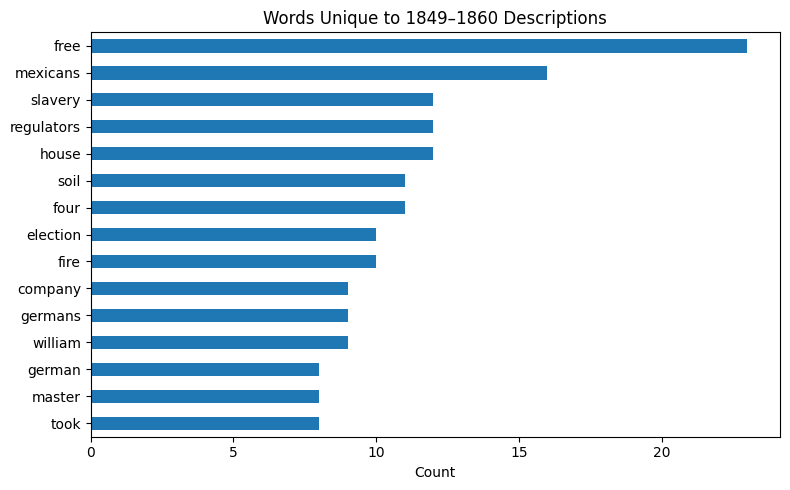

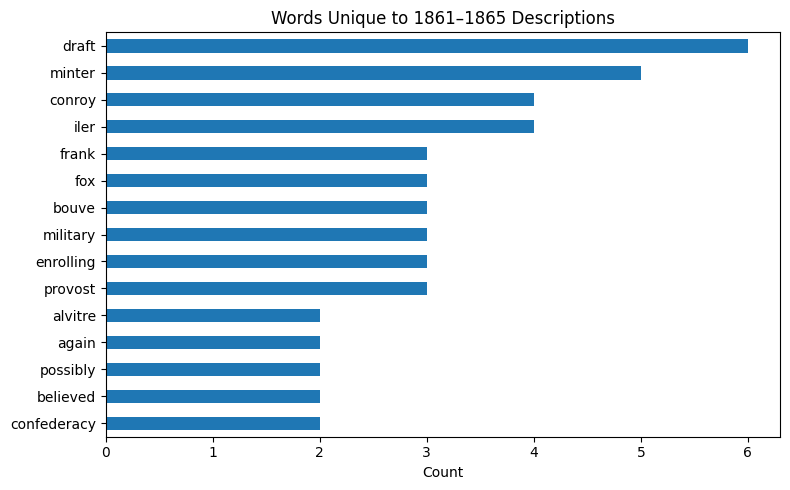


Average recorded deaths by incident group:


,avg_recorded_killed
incident_group,
Other,2.47
Racial/Slavery-Related,3.07


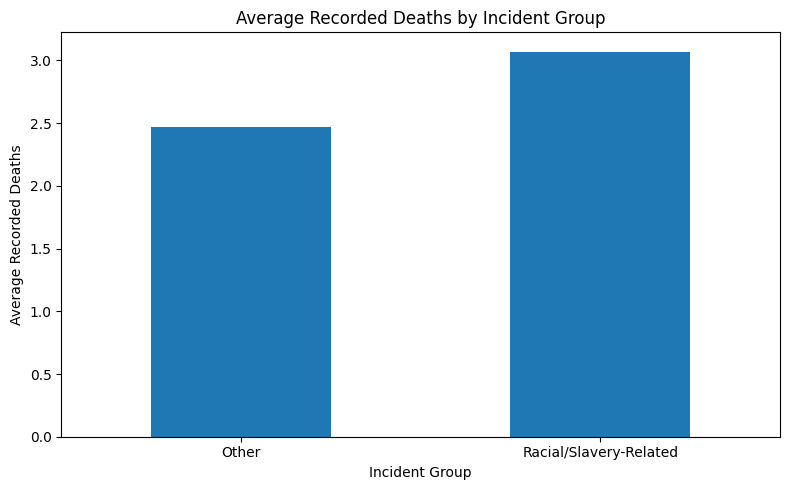


Saved cleaned dataset as 'cleaned_killings_1849_1865.csv'


In [4]:
# ============================================
# MVP PROJECT: Extralegal Killings, 1849–1865
# Comparative + NLP + Simple Predictive Proxy
# Historical Question:
# Did different regions exhibit distinct types
# of extralegal violence, with racialized or
# slavery-related violence forming a larger share
# of incidents in the South/Border South than in
# the West/North between 1849 and 1865?
# ============================================

# -----------------------------
# 1. Import libraries
# -----------------------------
import json
import pandas as pd
import matplotlib.pyplot as plt
import re

# -----------------------------
# 2. Load the GeoJSON file
# -----------------------------
file_path = "Year_1849_1865.geojson"

with open(file_path, "r", encoding="utf-8") as f:
    geojson_data = json.load(f)

records = [feature["properties"] for feature in geojson_data["features"]]
df = pd.DataFrame(records)

print("Dataset loaded.")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print("\nColumns:")
print(df.columns.tolist())

display(df.head())

# -----------------------------
# 3. Basic cleaning
# -----------------------------
df = df.copy()
df.columns = [col.strip() for col in df.columns]

text_cols = [
    "State", "Sublocation", "Location", "Description", "Source", "Type",
    "Rioter Classification", "Target Classification", "Actions", "Note"
]

for col in text_cols:
    if col in df.columns:
        df[col] = df[col].fillna("").astype(str).str.strip()

if "Year" in df.columns:
    df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
    df = df.dropna(subset=["Year"])
    df["Year"] = df["Year"].astype(int)

for col in ["Lat", "Long", "Recorded # Killed", "Recorded # Injured"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

print("\nShape after cleaning:", df.shape)

# -----------------------------
# 4. Create region variable
# -----------------------------
south_border_states = {
    "Delaware", "Maryland", "Virginia", "North Carolina", "South Carolina",
    "Georgia", "Kentucky", "Tennessee", "Louisiana", "Mississippi",
    "Alabama", "Missouri", "Arkansas", "Florida", "Texas"
}

def assign_region(state):
    state = str(state).strip()
    if state in south_border_states:
        return "South/Border South"
    return "West/North"

df["region"] = df["State"].apply(assign_region)

print("\nCounts by region:")
display(df["region"].value_counts().to_frame("count"))

# -----------------------------
# 5. Create target variable
# -----------------------------
def classify_incident_type(type_text):
    type_text = str(type_text).lower()
    if ("racial" in type_text) or ("slavery" in type_text):
        return "Racial/Slavery-Related"
    return "Other"

df["incident_group"] = df["Type"].apply(classify_incident_type)

print("\nCounts by incident group:")
display(df["incident_group"].value_counts().to_frame("count"))

# -----------------------------
# 6. Comparative calculation
# -----------------------------
comparison_counts = pd.crosstab(df["region"], df["incident_group"])
comparison_percent = pd.crosstab(df["region"], df["incident_group"], normalize="index") * 100

print("\nRaw counts by region and incident group:")
display(comparison_counts)

print("\nPercentages within each region:")
display(comparison_percent.round(2))

# -----------------------------
# 7. Comparative visualizations
# -----------------------------
comparison_percent.plot(kind="bar", figsize=(9, 6))
plt.title("Share of Racial/Slavery-Related Violence by Region, 1849–1865")
plt.xlabel("Region")
plt.ylabel("Percent of Incidents")
plt.xticks(rotation=0)
plt.legend(title="Incident Group")
plt.tight_layout()
plt.show()

comparison_percent.plot(kind="bar", stacked=True, figsize=(9, 6))
plt.title("Composition of Extralegal Violence by Region, 1849–1865")
plt.xlabel("Region")
plt.ylabel("Percent of Incidents")
plt.xticks(rotation=0)
plt.legend(title="Incident Group", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# -----------------------------
# 8. State-level breakdown
# -----------------------------
state_counts = pd.crosstab(df["State"], df["incident_group"])
state_counts["total_incidents"] = state_counts.sum(axis=1)

state_counts_filtered = state_counts[state_counts["total_incidents"] >= 4].drop(columns="total_incidents")

print("\nState-level counts (states with at least 4 incidents):")
display(state_counts_filtered.sort_values(by=state_counts_filtered.columns.tolist(), ascending=False))

state_counts_filtered.plot(kind="bar", figsize=(12, 6))
plt.title("Incident Group by State, 1849–1865")
plt.xlabel("State")
plt.ylabel("Number of Incidents")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Incident Group")
plt.tight_layout()
plt.show()

# -----------------------------
# 9. Create time period
# -----------------------------
def assign_period(year):
    if year <= 1860:
        return "1849–1860"
    return "1861–1865"

df["period"] = df["Year"].apply(assign_period)

period_percent = pd.crosstab(df["period"], df["incident_group"], normalize="index") * 100

print("\nPercentages by time period:")
display(period_percent.round(2))

period_percent.plot(kind="bar", figsize=(9, 6))
plt.title("Composition of Extralegal Violence by Time Period")
plt.xlabel("Period")
plt.ylabel("Percent of Incidents")
plt.xticks(rotation=0)
plt.legend(title="Incident Group")
plt.tight_layout()
plt.show()

# -----------------------------
# 10. SIMPLE PREDICTIVE / PROBABILISTIC PROXY
# No sklearn needed
# -----------------------------
# Convert target into binary numeric variable
df["target_binary"] = df["incident_group"].apply(
    lambda x: 1 if x == "Racial/Slavery-Related" else 0
)

# Probability by region
region_prob = df.groupby("region")["target_binary"].mean().sort_values(ascending=False)

print("\nProbability of racial/slavery-related incident by region:")
display(region_prob.to_frame("probability"))

region_prob.plot(kind="bar", figsize=(8, 5))
plt.title("Probability of Racial/Slavery-Related Violence by Region")
plt.xlabel("Region")
plt.ylabel("Probability")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Probability by state
state_prob = df.groupby("State")["target_binary"].mean()
state_count = df.groupby("State").size()

state_summary = pd.DataFrame({
    "probability": state_prob,
    "count": state_count
})

# Keep only states with at least 4 incidents for stability
state_summary = state_summary[state_summary["count"] >= 4]
state_summary = state_summary.sort_values("probability", ascending=False)

print("\nStates with the highest probability of racial/slavery-related incidents:")
display(state_summary.head(10))

state_summary.head(10)["probability"].sort_values().plot(kind="barh", figsize=(8, 5))
plt.title("Top States by Probability of Racial/Slavery-Related Violence")
plt.xlabel("Probability")
plt.tight_layout()
plt.show()

# Probability by target classification
if "Target Classification" in df.columns:
    target_prob = df.groupby("Target Classification")["target_binary"].mean()
    target_count = df.groupby("Target Classification").size()

    target_summary = pd.DataFrame({
        "probability": target_prob,
        "count": target_count
    })

    target_summary = target_summary[target_summary["count"] >= 3]
    target_summary = target_summary.sort_values("probability", ascending=False)

    print("\nTarget classifications most associated with racial/slavery-related violence:")
    display(target_summary.head(10))

    target_summary.head(10)["probability"].sort_values().plot(kind="barh", figsize=(8, 5))
    plt.title("Top Target Classifications by Probability")
    plt.xlabel("Probability")
    plt.tight_layout()
    plt.show()

# -----------------------------
# 11. NLP setup: tokenize and remove stopwords
# -----------------------------
stopwords = {
    "the", "a", "an", "and", "or", "of", "to", "in", "on", "for", "by",
    "with", "was", "were", "is", "are", "at", "as", "from", "that", "this",
    "it", "his", "her", "their", "them", "he", "she", "they", "after",
    "before", "when", "into", "out", "then", "than", "had", "has", "have",
    "be", "been", "being", "who", "which", "also", "not", "but", "one",
    "two", "three", "said", "would", "there", "about", "upon", "january",
    "february", "march", "april", "may", "june", "july", "august",
    "september", "october", "november", "december", "men", "man"
}

def tokenize(text):
    words = re.findall(r"\b[a-z]+\b", str(text).lower())
    return [word for word in words if word not in stopwords and len(word) > 2]

def top_words(series, n=12):
    all_words = []
    for text in series.dropna():
        all_words.extend(tokenize(text))
    if len(all_words) == 0:
        return pd.Series(dtype=int)
    return pd.Series(all_words).value_counts().head(n)

# -----------------------------
# 12. NLP output by incident group
# -----------------------------
racial_words = top_words(df[df["incident_group"] == "Racial/Slavery-Related"]["Description"])
other_words = top_words(df[df["incident_group"] == "Other"]["Description"])

print("\nTop words in racial/slavery-related descriptions:")
display(racial_words.to_frame("count"))

print("\nTop words in other descriptions:")
display(other_words.to_frame("count"))

if len(racial_words) > 0:
    racial_words.sort_values().plot(kind="barh", figsize=(8, 5))
    plt.title("Top Words in Racial/Slavery-Related Descriptions")
    plt.xlabel("Count")
    plt.tight_layout()
    plt.show()

if len(other_words) > 0:
    other_words.sort_values().plot(kind="barh", figsize=(8, 5))
    plt.title("Top Words in Other Descriptions")
    plt.xlabel("Count")
    plt.tight_layout()
    plt.show()

# -----------------------------
# 13. Stronger NLP section:
# distinctive words by time period
# -----------------------------
prewar_text = " ".join(df[df["period"] == "1849–1860"]["Description"].dropna())
war_text = " ".join(df[df["period"] == "1861–1865"]["Description"].dropna())

prewar_words = tokenize(prewar_text)
war_words = tokenize(war_text)

prewar_freq = pd.Series(prewar_words).value_counts()
war_freq = pd.Series(war_words).value_counts()

print("\nMost common words in 1849–1860 descriptions:")
display(prewar_freq.head(15).to_frame("count"))

print("\nMost common words in 1861–1865 descriptions:")
display(war_freq.head(15).to_frame("count"))

prewar_unique = prewar_freq[~prewar_freq.index.isin(war_freq.index)].head(15)
war_unique = war_freq[~war_freq.index.isin(prewar_freq.index)].head(15)

print("\nWords unique to 1849–1860:")
display(prewar_unique.to_frame("count"))

print("\nWords unique to 1861–1865:")
display(war_unique.to_frame("count"))

if len(prewar_unique) > 0:
    prewar_unique.sort_values().plot(kind="barh", figsize=(8, 5))
    plt.title("Words Unique to 1849–1860 Descriptions")
    plt.xlabel("Count")
    plt.tight_layout()
    plt.show()

if len(war_unique) > 0:
    war_unique.sort_values().plot(kind="barh", figsize=(8, 5))
    plt.title("Words Unique to 1861–1865 Descriptions")
    plt.xlabel("Count")
    plt.tight_layout()
    plt.show()

# -----------------------------
# 14. Optional severity comparison
# -----------------------------
if "Recorded # Killed" in df.columns:
    severity = df.groupby("incident_group")["Recorded # Killed"].mean().dropna()

    print("\nAverage recorded deaths by incident group:")
    display(severity.round(2).to_frame("avg_recorded_killed"))

    if len(severity) > 0:
        severity.plot(kind="bar", figsize=(8, 5))
        plt.title("Average Recorded Deaths by Incident Group")
        plt.xlabel("Incident Group")
        plt.ylabel("Average Recorded Deaths")
        plt.xticks(rotation=0)
        plt.tight_layout()
        plt.show()

# -----------------------------
# 15. Save cleaned data
# -----------------------------
df.to_csv("cleaned_killings_1849_1865.csv", index=False)
print("\nSaved cleaned dataset as 'cleaned_killings_1849_1865.csv'")